<a href="https://colab.research.google.com/github/MohammadJoenathan/Penerapan-Metode-LSA-untuk-Text-Summarization-pada-Dokumen-UU-PDP/blob/main/Penerapan_Latent_Semantic_Analysis_(LSA)_untuk_Text_Summarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Menghubungkan Google Colab dengan Google Drive

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#2. Install Library yang Dibutuhkan

In [107]:
!pip install pymupdf
!pip install sumy
!pip install nltk
!pip install pandas
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=05172d096b65a3fe9c0455485bdd9cf4f0ff75eff39bb76053771be98a181e07
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


#3. Import Library

In [108]:
import re
import pandas as pd
import nltk
import fitz

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer
from rouge_score import rouge_scorer

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

#4. Membaca Dokumen PDF

In [124]:
pdf_path = "/content/drive/MyDrive/Colab Notebooks/UU/UU Nomor 27 Tahun 2022.pdf"

doc = fitz.open(pdf_path)

teks = ""

for page in doc:
    teks += page.get_text("text") + " "
print(teks[:1000])

Hasil publikasi ulang oleh Perpajakan DDTC. Baca di platform.
Menemukan kesalahan ketik? Klik di sini agar kami dapat memperbaikinya.
UNDANG-UNDANG REPUBLIK INDONESIA
NOMOR 27 TAHUN 2022
TENTANG
PELINDUNGAN DATA PRIBADI
DENGAN RAHMAT TUHAN YANG MAHA ESA
PRESIDEN REPUBLIK INDONESIA,
Menimbang
a.
bahwa pelindungan data pribadi merupakan salah satu hak asasi manusia yang
merupakan bagian dari pelindungan diri pribadi maka perlu diberikan landasan
hukum untuk memberikan keamanan atas data pribadi, berdasarkan Undang-
Undang Dasar Negara Republik Indonesia Tahun 1945;
b.
bahwa pelindungan data pribadi ditujukan untuk menjamin hak warga negara
atas pelindungan diri pribadi dan menumbuhkan kesadaran masyarakat serta
menjamin pengakuan dan penghormatan atas pentingnya pelindungan data
pribadi;
c.
bahwa pengaturan data pribadi saat ini terdapat di dalam beberapa peraturan
perundang-undangan maka untuk meningkatkan efektivitas dalam pelaksanaan
pelindungan data pribadi diperlukan pengaturan meng

#5. Preprocessing Teks

In [111]:
teks_bersih = teks.lower()

teks_bersih = re.sub(r'hasil publikasi ulang oleh perpajakan ddtc.*?platform\.', ' ', teks_bersih)
teks_bersih = re.sub(r'menemukan kesalahan ketik.*?memperbaikinya\.', ' ', teks_bersih)

teks_bersih = re.sub(r'\d+\s*/\s*\d+', ' ', teks_bersih)

teks_bersih = teks_bersih.replace('￾', ' ')
teks_bersih = teks_bersih.replace('undang undang', 'undang-undang')
teks_bersih = teks_bersih.replace('perundang undangan', 'perundang-undangan')

teks_bersih = re.sub(r'\(\d+\)', ' ', teks_bersih)
teks_bersih = re.sub(r'\b[a-z]\.\s+', ' ', teks_bersih)
teks_bersih = re.sub(r'[^a-zA-Z\s\.]', ' ', teks_bersih)
teks_bersih = re.sub(r'\s+', ' ', teks_bersih).strip()

print(teks_bersih[:3000])

undang undang republik indonesia nomor tahun tentang pelindungan data pribadi dengan rahmat tuhan yang maha esa presiden republik indonesia menimbang bahwa pelindungan data pribadi merupakan salah satu hak asasi manusia yang merupakan bagian dari pelindungan diri pribadi maka perlu diberikan landasan hukum untuk memberikan keamanan atas data pribadi berdasarkan undang undang dasar negara republik indonesia tahun bahwa pelindungan data pribadi ditujukan untuk menjamin hak warga negara atas pelindungan diri pribadi dan menumbuhkan kesadaran masyarakat serta menjamin pengakuan dan penghormatan atas pentingnya pelindungan data pribadi bahwa pengaturan data pribadi saat ini terdapat di dalam beberapa peraturan perundang undangan maka untuk meningkatkan efektivitas dalam pelaksanaan pelindungan data pribadi diperlukan pengaturan mengenai pelindungan data pribadi dalam suatu undang undang bahwa berdasarkan pertimbangan sebagaimana dimaksud dalam huruf a huruf b dan huruf c perlu membentuk und

#6. Menghitung Jumlah Kata Dokumen Asli

In [112]:
jumlah_kata_asli = len(teks_bersih.split())

print("Jumlah kata dokumen asli:", jumlah_kata_asli)

Jumlah kata dokumen asli: 7432


#7. Latent Semantic Analysis (LSA) untuk Text Summarization

In [117]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer

parser = PlaintextParser.from_string(
    teks_bersih,
    Tokenizer("english")
)

summarizer = LsaSummarizer()

summary = summarizer(parser.document, 30)

ringkasan = "\n\n".join([str(sentence) for sentence in summary])

print(ringkasan)

pasal subjek data pribadi berhak untuk mengajukan keberatan atas tindakan pengambilan keputusan yang hanya didasarkan pada pemrosesan secara otomatis termasuk pemrofilan yang menimbulkan akibat hukum atau berdampak signifikan pada subjek data pribadi.

ketentuan lebih lanjut mengenai pengajuan keberatan atas pemrosesan secara otomatis sebagaimana dimaksud pada ayat diatur dalam peraturan pemerintah.

ketentuan lebih lanjut mengenai pelanggaran pemrosesan data pribadi dan tata cara pengenaan ganti rugi sebagaimana dimaksud pada ayat diatur dalam peraturan pemerintah.

ketentuan lebih lanjut mengenai pelaksanaan pemrosesan data pribadi sebagaimana dimaksud pada ayat diatur dalam peraturan pemerintah.

ketentuan lebih lanjut mengenai penilaian dampak pelindungan data pribadi diatur dalam peraturan pemerintah.

pengakhiran pemrosesan data pribadi sebagaimana dimaksud pada ayat dilakukan sesuai dengan ketentuan peraturan perundang undangan.

penghapusan data pribadi sebagaimana dimaksud pad

#8. Menghitung Jumlah Kata Hasil Ringkasan

In [127]:
jumlah_kata_ringkasan = len(ringkasan.split())

print("Jumlah kata ringkasan:", jumlah_kata_ringkasan)

Jumlah kata ringkasan: 750


#9. Evaluasi ROUGE

In [135]:
ringkasan_referensi = """
Undang-Undang Pelindungan Data Pribadi mengatur perlindungan terhadap data pribadi setiap warga negara.
Data pribadi harus diproses secara sah, terbatas, spesifik, transparan, dan bertanggung jawab.
Subjek data pribadi memiliki hak untuk memperoleh informasi, memperbaiki data, mengakses data, menarik persetujuan, serta menghapus data pribadinya.
Pengendali dan prosesor data pribadi wajib menjaga keamanan, kerahasiaan, dan akurasi data yang diproses.
Pemrosesan data pribadi harus dilakukan sesuai dengan tujuan yang jelas dan berdasarkan ketentuan peraturan perundang-undangan.
Pelanggaran terhadap ketentuan pelindungan data pribadi dapat dikenakan sanksi administratif maupun pidana.
Undang-Undang ini juga mengatur transfer data pribadi, penyelesaian sengketa, peran lembaga, dan partisipasi masyarakat dalam pelindungan data pribadi.
"""
scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

scores = scorer.score(
    ringkasan_referensi,
    ringkasan
)

for metric, score in scores.items():
    print(metric)
    print("Precision :", score.precision)
    print("Recall    :", score.recall)
    print("F1-Score  :", score.fmeasure)
    print()

rouge1
Precision : 0.08981233243967829
Recall    : 0.6442307692307693
F1-Score  : 0.1576470588235294

rouge2
Precision : 0.02953020134228188
Recall    : 0.21359223300970873
F1-Score  : 0.051886792452830184

rougeL
Precision : 0.057640750670241284
Recall    : 0.41346153846153844
F1-Score  : 0.10117647058823528



# 10. Menampilkan Hasil Evaluasi ROUGE

In [129]:
df_rouge = pd.DataFrame({
    "Metrik": ["ROUGE-1", "ROUGE-2", "ROUGE-L"],
    "Precision": [
        scores["rouge1"].precision,
        scores["rouge2"].precision,
        scores["rougeL"].precision
    ],
    "Recall": [
        scores["rouge1"].recall,
        scores["rouge2"].recall,
        scores["rougeL"].recall
    ],
    "F1-Score": [
        scores["rouge1"].fmeasure,
        scores["rouge2"].fmeasure,
        scores["rougeL"].fmeasure
    ]
})

df_rouge

,Metrik,Precision,Recall,F1-Score
0,ROUGE-1,0.089812,0.644231,0.157647
1,ROUGE-2,0.029530,0.213592,0.051887
2,ROUGE-L,0.057641,0.413462,0.101176


#11. Menghitung Compression Rate

In [130]:
persentase_kompresi = (
    (jumlah_kata_asli - jumlah_kata_ringkasan)
    / jumlah_kata_asli
) * 100

print(f"Persentase Kompresi: {persentase_kompresi:.2f}%")

Persentase Kompresi: 89.91%


#12. Menyimpan Hasil ke DataFrame

In [131]:
df_hasil = pd.DataFrame({
    "Judul": ["UU Perlindungan Data Pribadi"],
    "Jumlah Kata Asli": [jumlah_kata_asli],
    "Jumlah Kata Ringkasan": [jumlah_kata_ringkasan],
    "Persentase Kompresi": [persentase_kompresi]
})

df_hasil

,Judul,Jumlah Kata Asli,Jumlah Kata Ringkasan,Persentase Kompresi
0,UU Perlindungan Data Pribadi,7432,750,89.908504


#13. Visualisasi Hasil Summarization

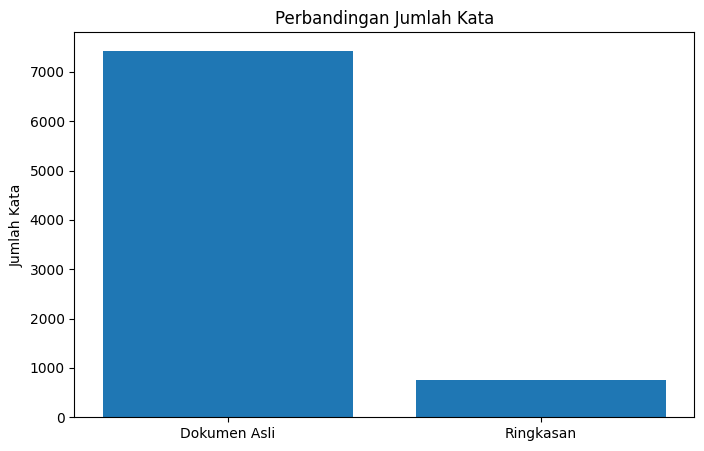

In [132]:
import matplotlib.pyplot as plt

data = [
    jumlah_kata_asli,
    jumlah_kata_ringkasan
]

label = [
    "Dokumen Asli",
    "Ringkasan"
]

plt.figure(figsize=(8,5))
plt.bar(label, data)

plt.title("Perbandingan Jumlah Kata")
plt.ylabel("Jumlah Kata")

plt.show()